In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [ ]:
accl_raw = pd.read_csv("/Users/salmaelaazdoudi/Documents/M2 DEPP/ASML/raw/all_accelerometer_data_pids_13.csv")

## Exploratory Analysis : Acceloremeter data

In [ ]:
accl_raw.head()

,time,pid,x,y,z
0,0,JB3156,0.0000,0.0000,0.0000
1,0,CC6740,0.0000,0.0000,0.0000
2,1493733882409,SA0297,0.0758,0.0273,-0.0102
3,1493733882455,SA0297,-0.0359,0.0794,0.0037
4,1493733882500,SA0297,-0.2427,-0.0861,-0.0163


In [ ]:
accl_raw.pid.unique()

array(['JB3156', 'CC6740', 'SA0297', 'PC6771', 'BK7610', 'DC6359',
       'MC7070', 'MJ8002', 'BU4707', 'JR8022', 'HV0618', 'SF3079',
       'DK3500'], dtype=object)

In [ ]:
def get_min_max_interval(df):
    """
    Return df with min, median and max time intervals
    (milliseconds) between accelerometer readings.
    """
    pids = []
    mins = []
    meds = []
    maxs = []
    for pid in list(df.pid.unique()):
        temp = df.loc[(df.pid==pid) & (df.time!=0)].reset_index(drop=True)
        temp = temp.sort_values('time', ascending=True)
        interval = temp[['time']].diff(axis=0)
        interval = interval.loc[interval.time.notna()]
        pids.append(pid)
        mins.append(interval.time.min())
        meds.append(interval.time.median())
        maxs.append(interval.time.max())
    return pd.DataFrame(zip(pids,mins,meds,maxs),
                        columns=['pid', 'Min Time Interval (ms)',
                                 'Median Time Interval (ms)',
                                 'Max Time Interval (ms)'])


In [ ]:
get_min_max_interval(accl_raw)

,pid,Min Time Interval (ms),Median Time Interval (ms),Max Time Interval (ms)
0,JB3156,0.0,20.0,114899.0
1,CC6740,0.0,25.0,2157503.0
2,SA0297,0.0,45.0,9366095.0
3,PC6771,0.0,25.0,21320666.0
4,BK7610,0.0,25.0,825778.0
5,DC6359,0.0,25.0,8148762.0
6,MC7070,0.0,25.0,15147211.0
7,MJ8002,0.0,25.0,12773235.0
8,BU4707,0.0,25.0,6588017.0
9,JR8022,0.0,26.0,12233634.0


The study reports that the acceloremeter recorded data at a 40 Hz sampling rate. This means that between each recording,
there should be a time interval of 25 ms. The very large maximum time intervals (ranging from several minutes to several hours)
indicate that the accelerometer did not record data continuously at 40 Hz. Although the median interval is close to 25 ms,
consistent with a 40 Hz sampling rate, the maximum gaps clearly show extended periods without any recorded measurements.

In [ ]:
def plot_acc_readings(df, pid):
    """
    Plot x, y, z accelerations for given pid over time.
    """
    # Limit to data for given pid.
    temp = df.loc[(df.pid==pid) & (df.time!=0)].reset_index(drop=True)
    temp['datetime'] = pd.to_datetime(temp['time'], unit='ms')

    plt.figure(figsize=(20,10))
    plt.subplot(3, 1, 1)
    plt.title(f"Accelerometer Data for {pid}")
    plt.plot(temp.datetime, temp.x, '.-')
    plt.ylabel('X acceleration')

    plt.subplot(3, 1, 2)
    plt.plot(temp.datetime, temp.y, '.-')
    plt.ylabel('Y acceleration')

    plt.subplot(3, 1, 3)
    plt.plot(temp.datetime, temp.z, '.-')
    plt.xlabel('Datetime (ms)')
    plt.ylabel('Z acceleration')

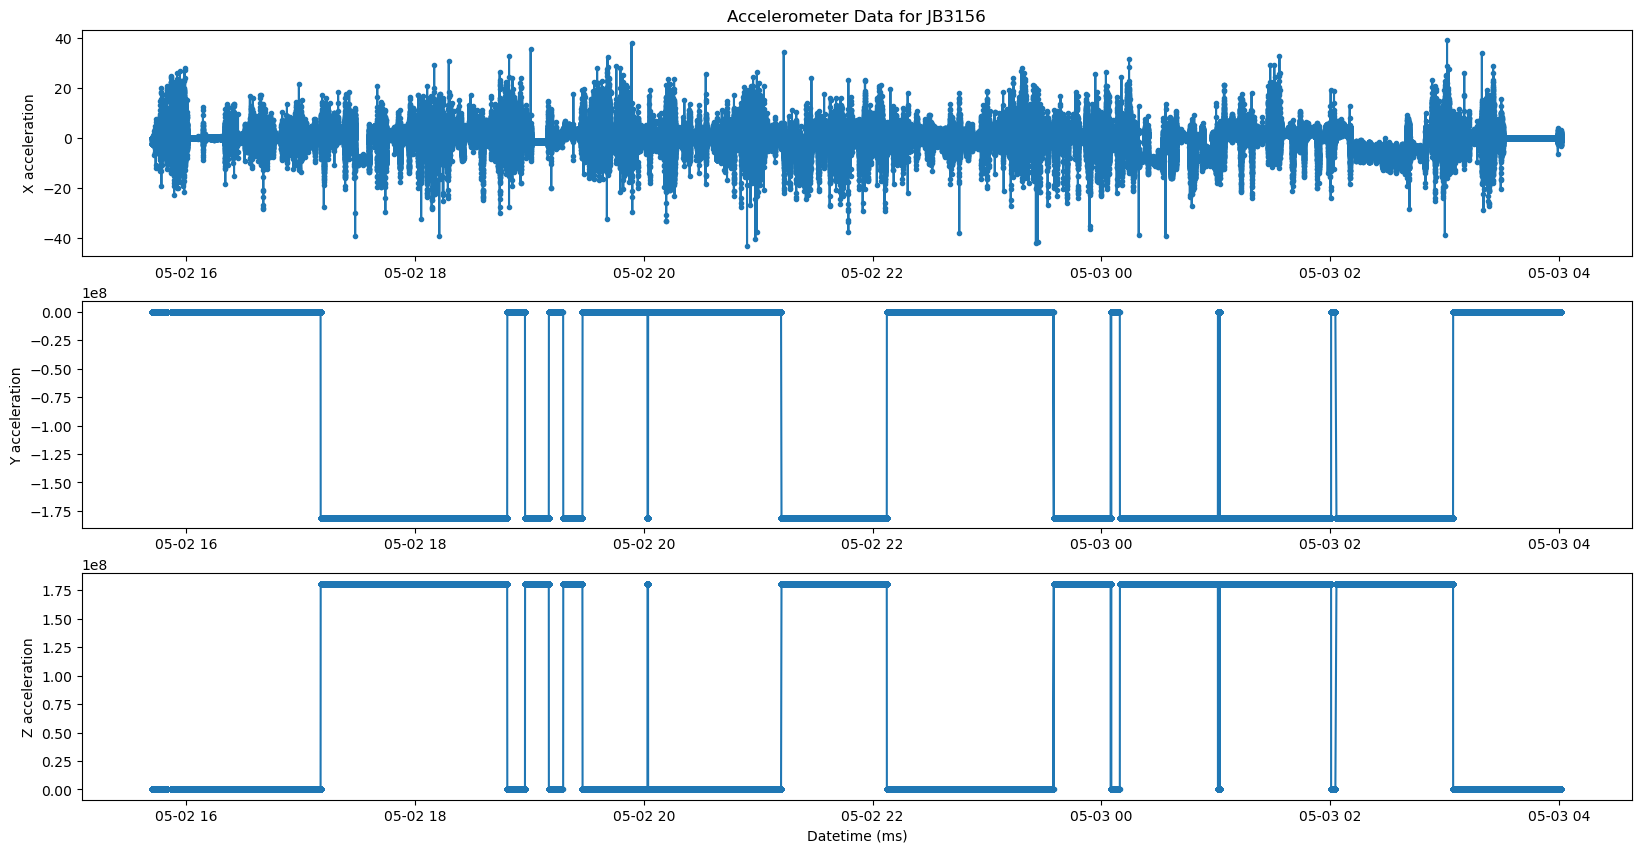

In [ ]:
plot_acc_readings(accl_raw, 'JB3156')

The X-axis data appears continuous and consistent with normal accelerometer behavior, but the Y and Z axes show long flat segments,
and abrupt jumps. This indicates that these axes were not recorded continuously. These patterns confirm the
presence of irregular sampling and corrupted or missing data.

## Pre-processing : Acceloremeter data

In [ ]:
def missing_data_imputation(df):
    """
    Standardize: generate max_timestamp (ms) - min_timestamp (ms)
    number of rows for a given df, so that there is a row for
    every millisecond.

    Impute: Fill in missing accelerometer readings with readings from the
    previous millisecond timestamp.

    Returns: array of timestamps and array of accelerometer readings.
    """
    min_timestamp = df['time'].min()
    max_timestamp = df['time'].max()
    min_timeinterval = 1

    print(min_timestamp, max_timestamp)

    array_size = int((max_timestamp-min_timestamp)/min_timeinterval) + 1
    # Initialize empty array of size array_size.
    accelerometer_readings = [None] * array_size

    # Add data to the arrays based on the readings.
    first_accelerometer_reading = None
    for i in range(0, len(df)):
        if(first_accelerometer_reading == None):
            first_accelerometer_reading = [
                df.loc[i, 'x'], df.loc[i, 'y'], df.loc[i, 'z']]
        index = int((df.loc[i, 'time'] - min_timestamp)/min_timeinterval)
        try:
            accelerometer_readings[index] = [
                df.loc[i, 'x'], df.loc[i, 'y'], df.loc[i, 'z']]
        except:  # If sensor readings are empty. -- Error
            pass

    prev_accelerometer = None
    for i in range(0, array_size):
        # If missing, add reading from previous timestamp.
        if(accelerometer_readings[i] == None):
            if(prev_accelerometer != None):
                accelerometer_readings[i] = prev_accelerometer
            else:
                accelerometer_readings[i] = first_accelerometer_reading
        # If not missing, skip row and do not override it.
        elif (accelerometer_readings[i] != None):
            prev_accelerometer = accelerometer_readings[i]

    return list(range(min_timestamp, max_timestamp+1)), accelerometer_readings

In [ ]:
def preprocess_acc(path, new_path):
    """
    Given a path load "all_accelerometer_data_pids_13.csv"
    and drop if missing time or zero accelerometer data.

    For each pid, standardize sampling frequency to every millisecond,
    impute missing data and save a pickle file for each pid to new_path.

    This function returns None.
    """
    # Create folder for new_path if does not exist.
    if not os.path.exists(new_path):
        os.makedirs(new_path)
    # Load file.
    df = pd.read_csv(path + "all_accelerometer_data_pids_13.csv")
    # Drop if missing timestamp.
    df = df.loc[df.time!=0]
    # Keep non-zero accelerometer data only.
    df = df.loc[(df.x!=0) & (df.y!=0) & (df.z!=0)]
    # For each pid, standardize sampling frequency to 1 millisecond.
    for current_pid in list(df.pid.unique()):
	    print(f"Preprocessing: {current_pid}")
	    # Filter on pid.
	    temp = df.loc[df.pid == current_pid].sort_values(
	        'time', ascending=True).reset_index(drop=True)
	    print(f"Original shape: {temp.shape}")
	    timestamps, readings = missing_data_imputation(temp)
	    # Create df with timestamps and readings.
	    new_df = pd.DataFrame(readings, columns=["x", "y", "z"])
	    new_df['time'] = timestamps
	    new_df['pid'] = current_pid
	    # Print new df shape.
	    print(f"New shape: {new_df.shape}")
	    # Export preproccessed data as a pickle file.
	    new_df.to_pickle(new_path + current_pid +
	    				"_preprocessed_acc.pkl")
    print("Preprocessing complete and files exported.")
    return None

In [ ]:
# Pre-process accelerometer data for each pid and save as pkl file.
path = "/Users/salmaelaazdoudi/Documents/M2 DEPP/ASML/raw/"
new_path = "/Users/salmaelaazdoudi/Documents/M2 DEPP/ASML/preprocessed_data/"
preprocess_acc(path, new_path)

Preprocessing: SA0297
Original shape: (923451, 5)
1493733882409 1493824735776
New shape: (90853368, 5)
Preprocessing: PC6771
Original shape: (2073372, 5)
1493735288409 1493821488372
New shape: (86199964, 5)
Preprocessing: BK7610
Original shape: (1176530, 5)
1493735870653 1493767770640
New shape: (31899988, 5)
Preprocessing: DC6359
Original shape: (578394, 5)
1493736440950 1493769017080
New shape: (32576131, 5)
Preprocessing: MC7070
Original shape: (307866, 5)
1493736657665 1493781545272
New shape: (44887608, 5)
Preprocessing: MJ8002
Original shape: (613982, 5)
1493736949591 1493784951985
New shape: (48002395, 5)
Preprocessing: BU4707
Original shape: (443875, 5)
1493737404780 1493757822097
New shape: (20417318, 5)
Preprocessing: JR8022
Original shape: (299825, 5)
1493737962462 1493772061028
New shape: (34098567, 5)
Preprocessing: HV0618
Original shape: (1795520, 5)
1493738907489 1493825233785
New shape: (86326297, 5)
Preprocessing: SF3079
Original shape: (654301, 5)
1493739196712 149379

## Exploratory Analysis : TAC data

In [ ]:
def preprocess_tac(path):
    """
    Given a path to the "clean_tac" folder,
    append all tac files in directory and create a pid variable.

    Convert "TAC_Reading" into binary "intoxicated" variable:
    intoxicated = 1 if TAC_Reading > 0.08,
    intoxicated = 0 if TAC_Reading <= 0.08.

	Returns concatenated dataframe with all pids.
    """
    appended_data = []
    directory = os.fsencode(path)
    for file in os.listdir(directory):
        filename = os.fsdecode(file)
        df = pd.read_csv(path + filename)
        df['pid'] = filename.split("_")[0]
        appended_data.append(df)
    df = pd.concat(appended_data).sort_values(['timestamp'], ascending=True).reset_index(drop=True)
    # Create binary flag.
    df.loc[df.TAC_Reading > 0.08, "intoxicated"] = 1
    df.loc[df.TAC_Reading <= 0.08, "intoxicated"] = 0
    return df

In [ ]:
# Pre-process clean_tac data.
tac = preprocess_tac(path + "clean_tac/")

In [ ]:
def plot_tac_readings(tac):
    """
    Plot raw TAC_Readings by subject pid over datetime.
    """
    # Create folder for plots if does not exist.
    if not os.path.exists('plots'):
        os.makedirs('plots')
    # Set plot size.
    plt.figure(figsize=(20,5))
    # Create datetime for reference in plot.
    tac['datetime'] = pd.to_datetime(tac['timestamp'], unit='s')
    for pid, group in tac.groupby("pid"):
        plt.plot(group["datetime"], group["TAC_Reading"], marker="o",
            linestyle="", label=pid)
    plt.axhline(y=0.08, color='r', linestyle='-')
    plt.title("TAC Readings Over Time By Subject")
    plt.xlabel("Datetime")
    plt.legend()

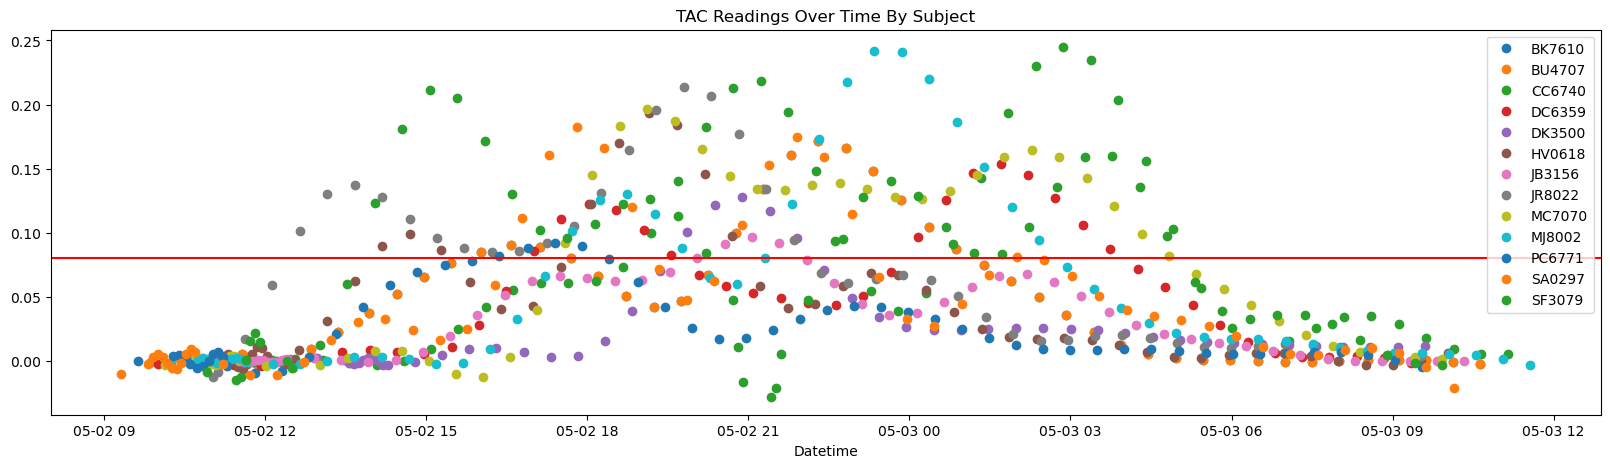

In [ ]:
# Plot TAC readings over time by subject.
plot_tac_readings(tac)

In [ ]:
def plot_class_balance(tac, title):
    """
    Plot class frequency and percentage.
    """
     # Create folder for plots if does not exist.
    if not os.path.exists('plots'):
        os.makedirs('plots')
    intox = tac[['intoxicated','pid']].groupby('intoxicated').\
        agg({'pid':'count'}).reset_index()
    intox['intoxicated'] = intox['intoxicated'].astype('int').astype('str')
    plt.bar(intox.intoxicated, height=intox.pid)
    # Percent labels.
    total = intox.pid.sum()
    for i, v in enumerate(intox.pid):
        plt.text(i - .08, v -(total/10), str("{:.0%}".format(v/total)),
                 fontsize = 12, fontweight='bold')
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Frequency')

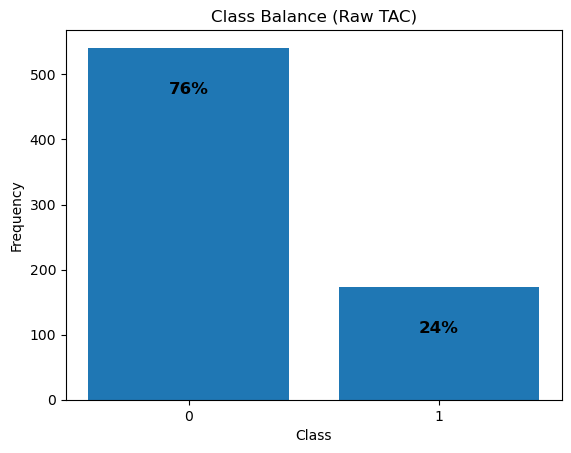

In [ ]:
# Plot class balance.
plot_class_balance(tac,'Class Balance (Raw TAC)')

The study states that TAC readings were collected every 30 minutes, at a much slower rate than the accelerometer data. The graph below
shows the spread of raw TAC readings by pid, with the "intoxicated" threshold of 0.08 in red. It looks like there might be potential issues
with class imbalance.

## Feature Engineering

### Helper functions for acceloremeter data feature engineering

In [ ]:
# Helper functions.
def zero_crossing(x):
    """
    Count the number of times the signal value changed signs.
    """
    return sum((x.iloc[:-1] * x.shift(-1).iloc[:-1]) < 0)

In [ ]:
def percentile(p):
    """
    Helper function to compute percentile p.
    """
    def percentile_(x):
        return np.percentile(x, p)
    percentile_.__name__ = 'percentile_%s' % p
    return percentile_

In [ ]:
def add_mean_last3(w1_df, w10_df):
    """
    Compute mean of last 3 seconds from each 10-second window and join back
    to w10 dataframe.
    """
    new = w1_df.groupby(['pid', 'window10']).tail(3).groupby(['pid', 'window10']).mean().reset_index()\
        .drop(['window1'], axis=1)
    new.columns = ['_'.join([col, 'last3']) for col in new.columns.values]
    new = new.rename(columns={'pid_last3': 'pid',
                              'window10_last3': 'window10'})
    return pd.merge(w10_df, new, how='left', on=['pid', 'window10'])

In [ ]:
def add_mean_first3(w1_df, w10_df):
    """
    Compute mean of first 3 seconds from each 10-second window
    and join back to w10 dataframe.
    """
    new = w1_df.groupby(['pid', 'window10']).head(3).groupby(['pid', 'window10']).mean().reset_index()\
        .drop(['window1'], axis=1)
    new.columns = ['_'.join([col, 'first3']) for col in new.columns.values]
    new = new.rename(columns={'pid_first3': 'pid',
                              'window10_first3': 'window10'})
    return pd.merge(w10_df, new, how='left', on=['pid', 'window10'])

In [ ]:
# Windowing functions.
def pivot_window_10s_from_ms(df):
    """
    Given millisecond-level data, compute 'mean', median', 'min', 'max', 'std',
    percentiles, and zero-crossing per 10-second window.
    Pivot into a single row (uniquely identified by window10-pid).
    """
    df['window10'] = np.floor(df['time'] / 10000).astype(int)
    df = df.groupby(['pid', 'window10'])[['x', 'y', 'z']]\
        .agg(['mean', 'median', 'min', 'max', 'std',
              percentile(5), percentile(25), percentile(75), percentile(95), zero_crossing])
    df.columns = ['_'.join([str(c) for c in col]).strip()
                  for col in df.columns.values]
    df = df.reset_index()
    return df.reset_index()

### Add spectral features

In [ ]:
import numpy as np
import scipy.fft

# --- 1. Energy Features ---
def calculate_energy(x):
    """Computes the energy of the signal: sum(x^2) / N"""
    return np.sum(x**2) / len(x)

def calculate_energy_entropy(x, n_blocks=10):
    """Computes entropy of energy distribution over the window"""
    x = np.array(x) # Ensure numpy array
    N = len(x)
    if N < n_blocks: return 0.0

    # Truncate to be perfectly divisible by n_blocks
    M = N // n_blocks
    x_trunc = x[:M*n_blocks]

    # Reshape into 10 blocks
    sub_wins = x_trunc.reshape(n_blocks, M)

    # Compute energy of each block
    e_sub = np.sum(sub_wins**2, axis=1)

    # Normalize to get probabilities (add small epsilon to avoid div by 0)
    e_total = np.sum(x**2) + 1e-10
    probs = e_sub / e_total

    # Compute entropy
    # Add epsilon inside log to avoid log(0)
    entropy = -np.sum(probs * np.log2(probs + 1e-10))
    return entropy

# --- 2. Spectral (Frequency) Features ---
def get_spectral_centroid(x):
    """Weighted mean of the frequencies present in the signal"""
    # fs = 1000 Hz (because your imputation makes it 1 row per ms)
    fs = 1000
    x = np.array(x)
    N = len(x)
    if N == 0: return 0.0

    # Compute FFT (Fast Fourier Transform)
    # We use rfft (real FFT) which gives us just the positive frequencies
    fft_vals = np.abs(scipy.fft.rfft(x))
    freqs = scipy.fft.rfftfreq(N, 1/fs)

    # Calculate Centroid
    sum_fft = np.sum(fft_vals)
    if sum_fft == 0: return 0.0

    centroid = np.sum(freqs * fft_vals) / sum_fft
    return centroid

def get_spectral_spread(x):
    """Standard deviation of the frequencies around the centroid"""
    fs = 1000
    x = np.array(x)
    N = len(x)
    if N == 0: return 0.0

    fft_vals = np.abs(scipy.fft.rfft(x))
    freqs = scipy.fft.rfftfreq(N, 1/fs)

    sum_fft = np.sum(fft_vals)
    if sum_fft == 0: return 0.0

    centroid = np.sum(freqs * fft_vals) / sum_fft

    # Spread
    spread = np.sqrt(np.sum(((freqs - centroid) ** 2) * fft_vals) / sum_fft)
    return spread

In [ ]:
def pivot_window_10s_from_ms(df):
    """
    windowing function with Spectral Features.
    """
    # 1. Create 10-second Window ID
    df['window10'] = np.floor(df['time'] / 10000).astype(int)

    # 2. Define all features to calculate
    # We treat energy_entropy special to pass the n_blocks argument if needed
    energy_entropy_wrapper = lambda x: calculate_energy_entropy(x, n_blocks=10)
    energy_entropy_wrapper.__name__ = 'energy_entropy' # naming for column headers

    feature_funcs = [
        'mean', 'median', 'min', 'max', 'std',
        percentile(5), percentile(25), percentile(75), percentile(95),
        zero_crossing,
        calculate_energy,
        energy_entropy_wrapper,
        get_spectral_centroid,
        get_spectral_spread
    ]

    # 3. Apply aggregation
    # This takes time because it runs FFT on every window!
    df_agg = df.groupby(['pid', 'window10'])[['x', 'y', 'z']].agg(feature_funcs)

    # 4. Flatten column names (e.g., "x_get_spectral_centroid")
    df_agg.columns = ['_'.join([str(c) for c in col]).strip() for col in df_agg.columns.values]

    # 5. Reset index to make pid and window10 normal columns
    return df_agg.reset_index()

### resume feature engineering

In [ ]:
def pivot_window_1s(df):
    """
    Compute 'mean', median', 'min', 'max', 'std' per 1-second window per pid
    and pivot into a single row (uniquely identified by window1-pid).

    Input df columns: ['x', 'y', 'z']
    Output df columns: ['x_median', 'x_min',...'z_median']
    """
    df['window1'] = np.floor(df['time'] / 1000).astype(int)
    df = df.groupby(['pid', 'window1'])[['x', 'y', 'z']]\
        .agg(['mean', 'median', 'min', 'max', 'std'])
    df.columns = ['_'.join([str(c) for c in col]).strip()
                  for col in df.columns.values]
    return df.reset_index()

In [ ]:
def pivot_window_10s_from_1s(df):
    """
    Calls pivot_window_1s to compute 1-second window metrics.

    Compute 'mean', median', 'min', 'max', 'std', 'first3_mean', 'last3_mean',
    of computed 1-second window metrics per 10-second window per pid
    and pivot into a single row (uniquely identified by window10-pid).

    Input df columns: ['x_median', 'y_median','z_median',...]
    Output df columns: ['x_median_mean', 'y_median_mean', 'z_median_mean', 'x_median_median',...]
    """
    w1 = pivot_window_1s(df)
    w1['window10'] = np.floor(w1['window1'] / 10).astype(int)
    two_tier_df = w1.groupby(['pid', 'window10'])[w1.drop(['pid', 'window1', 'window10'], axis=1).columns]\
        .agg(['mean', 'median', 'min', 'max', 'std'])
    two_tier_df.columns = ['_'.join([str(c) for c in col]).strip()
                           for col in two_tier_df.columns.values]
    two_tier_df = two_tier_df.reset_index()
    # Compute mean of first and last 3 seconds within the 10-second window.
    two_tier_df = add_mean_last3(w1, two_tier_df)
    two_tier_df = add_mean_first3(w1, two_tier_df)
    # Impute nan standard deviation (when window10 is a single row) as 0.
    two_tier_df = two_tier_df.fillna(0)
    return two_tier_df

In [ ]:
def two_tier_windowing(df):
    """
    Run single and two-tier windowing functions
    and merge generated features together.

    Returns a dataframe with all features.
    """
    single_tier = pivot_window_10s_from_ms(df)
    two_tier = pivot_window_10s_from_1s(df)
    return pd.merge(single_tier, two_tier, how='left', on=['pid', 'window10'])

In [ ]:
def run_feature_engineering(acc_path):
    """
    Load each preprocessed accelerometer file and
    create all features using two-tiered windowing.

    Returns a concatenated dataframe with
    accelerometer data for all participants.
    """
    dfs = []
    # Encode path to handle special characters if necessary
    directory = os.fsencode(acc_path)

    for file in os.listdir(directory):
        filename = os.fsdecode(file)

        # Skip hidden files like .DS_Store to avoid errors
        if filename.startswith('.'):
            continue

        print(f"Processing {filename}...")
        try:
            # Read pickle file
            df = pd.read_pickle(os.path.join(acc_path, filename))

            # Apply windowing and feature extraction
            df = two_tier_windowing(df)

            dfs.append(df)
        except Exception as e:
            print(f"Skipping {filename}: {e}")

    if not dfs:
        print("No files were processed.")
        return pd.DataFrame()

    # Concatenate all dataframes and automatically reset the index
    # This avoids the creation of 'level_0' or 'index' columns that caused your error
    return pd.concat(dfs, ignore_index=True)

In [ ]:
acc_path = "/Users/salmaelaazdoudi/Documents/M2 DEPP/ASML/preprocessed_data/"
full_acc = run_feature_engineering(acc_path)

Processing MC7070_preprocessed_acc.pkl...
Processing JR8022_preprocessed_acc.pkl...
Processing PC6771_preprocessed_acc.pkl...
Processing BK7610_preprocessed_acc.pkl...
Processing MJ8002_preprocessed_acc.pkl...
Processing SA0297_preprocessed_acc.pkl...
Processing DK3500_preprocessed_acc.pkl...
Processing DC6359_preprocessed_acc.pkl...
Processing SF3079_preprocessed_acc.pkl...
Processing HV0618_preprocessed_acc.pkl...
Processing JB3156_preprocessed_acc.pkl...
Processing CC6740_preprocessed_acc.pkl...
Processing BU4707_preprocessed_acc.pkl...


### Helper function for merge accelerometer (features) to TAC (target)

In [ ]:
# Joining target to features.
def reconcile_acc_tac(acc, tac):
    """
    Merge target "intoxicated" variable onto windowed accelerometer df by taking the most
    recent target value where tac timestamp (10s window) <= acc timestamp (10s window)
    for a given pid.
    """
    # Create window10 timestamp on tac df.
    tac['window10'] = np.floor(tac['timestamp'] / 10).astype(int)
    # Sort both df by window10.
    acc = acc.sort_values(['window10'], ascending=True)
    tac = tac.sort_values(['window10'], ascending=True)
    # Merge the last row in tac whose tac timestamp <= to the acc timestamp.
    return pd.merge_asof(acc, tac, on='window10', by='pid').reset_index(drop=True)

In [ ]:
# Join target onto features.
merged = reconcile_acc_tac(full_acc, tac)

In [ ]:
merged.shape

(72521, 153)

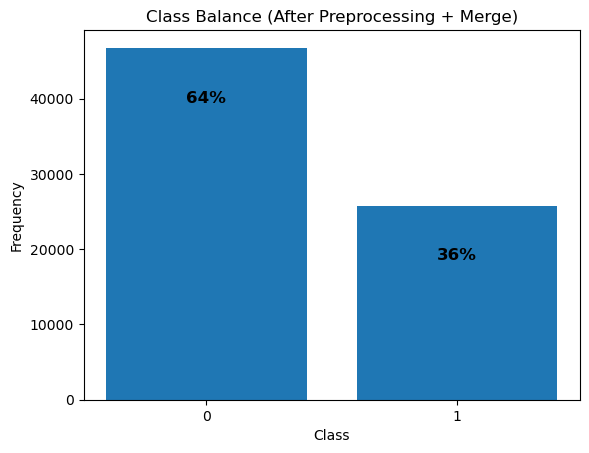

In [ ]:
# Class balance after merge.
plot_class_balance(merged,'Class Balance (After Preprocessing + Merge)')

In [ ]:
merged.head()

,pid,window10,x_mean,x_median,x_min,x_max,x_std,x_percentile_5,x_percentile_25,x_percentile_75,...,y_std_first3,z_mean_first3,z_median_first3,z_min_first3,z_max_first3,z_std_first3,timestamp,TAC_Reading,intoxicated,datetime
0,SA0297,149373388,-0.046270,-0.0026,-0.2888,0.1672,0.098936,-0.2427,-0.0202,0.0014,...,0.026359,-0.011375,-0.011833,-0.036933,0.005667,0.005126,1493732624,0.030566,0.0,2017-05-02 13:43:44
1,SA0297,149373389,0.007521,-0.0011,-0.2182,0.4063,0.067725,-0.0340,-0.0030,0.0017,...,0.005339,-0.001082,-0.002633,-0.056700,0.034500,0.019634,1493732624,0.030566,0.0,2017-05-02 13:43:44
2,SA0297,149373390,0.000888,-0.0002,-0.0107,0.2475,0.016792,-0.0052,-0.0022,0.0014,...,0.003269,-0.003082,-0.003050,-0.005567,0.001567,0.001655,1493732624,0.030566,0.0,2017-05-02 13:43:44
3,SA0297,149373391,0.000072,0.0001,-0.0124,0.0178,0.002788,-0.0041,-0.0014,0.0014,...,0.002325,-0.003131,-0.003067,-0.006267,-0.000600,0.001297,1493732624,0.030566,0.0,2017-05-02 13:43:44
4,SA0297,149373392,-0.000280,-0.0005,-0.0140,0.0128,0.002845,-0.0046,-0.0017,0.0011,...,0.004306,-0.002094,-0.001700,-0.005733,0.001100,0.001663,1493732624,0.030566,0.0,2017-05-02 13:43:44


In [ ]:
print(merged.columns)

Index(['pid', 'window10', 'x_mean', 'x_median', 'x_min', 'x_max', 'x_std',
       'x_percentile_5', 'x_percentile_25', 'x_percentile_75',
       ...
       'y_std_first3', 'z_mean_first3', 'z_median_first3', 'z_min_first3',
       'z_max_first3', 'z_std_first3', 'timestamp', 'TAC_Reading',
       'intoxicated', 'datetime'],
      dtype='object', length=153)


In [ ]:
print(merged.columns.tolist())

['pid', 'window10', 'x_mean', 'x_median', 'x_min', 'x_max', 'x_std', 'x_percentile_5', 'x_percentile_25', 'x_percentile_75', 'x_percentile_95', 'x_zero_crossing', 'x_calculate_energy', 'x_energy_entropy', 'x_get_spectral_centroid', 'x_get_spectral_spread', 'y_mean', 'y_median', 'y_min', 'y_max', 'y_std', 'y_percentile_5', 'y_percentile_25', 'y_percentile_75', 'y_percentile_95', 'y_zero_crossing', 'y_calculate_energy', 'y_energy_entropy', 'y_get_spectral_centroid', 'y_get_spectral_spread', 'z_mean', 'z_median', 'z_min', 'z_max', 'z_std', 'z_percentile_5', 'z_percentile_25', 'z_percentile_75', 'z_percentile_95', 'z_zero_crossing', 'z_calculate_energy', 'z_energy_entropy', 'z_get_spectral_centroid', 'z_get_spectral_spread', 'x_mean_mean', 'x_mean_median', 'x_mean_min', 'x_mean_max', 'x_mean_std', 'x_median_mean', 'x_median_median', 'x_median_min', 'x_median_max', 'x_median_std', 'x_min_mean', 'x_min_median', 'x_min_min', 'x_min_max', 'x_min_std', 'x_max_mean', 'x_max_median', 'x_max_min',

In [ ]:
merged.to_csv('/Users/salmaelaazdoudi/Documents/M2 DEPP/ASML/final_data/merged_data.csv', index=False)